# Basic

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import pickle
import numpy as np
import tqdm
import os
import glob
import multiprocessing as mp

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.eval as eval

# discover candidate lists

In [3]:
def to_type_dict(file_list):
    return {os.path.splitext(os.path.basename(f))[0]: f for f in file_list}

In [4]:
gd_tree_list = glob.glob(config.IACandidateLists().path_greedy_tree + '/*.parquet')
baseline_list = glob.glob(config.IACandidateLists().baseline_path + '/*.parquet')

all_candidates = {
    "greedy_tree_margin": to_type_dict(gd_tree_list),
    "baseline": to_type_dict(baseline_list),
}
for category, file_list in all_candidates.items():
    for file_type, file in file_list.items():
        print(f"Category: {category}, File Type: {file_type}, File: {file}")

Category: greedy_tree_margin, File Type: 0.0, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/greedy_tree_candidates/0.0.parquet
Category: greedy_tree_margin, File Type: 0.2, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/greedy_tree_candidates/0.2.parquet
Category: greedy_tree_margin, File Type: 0.4, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/greedy_tree_candidates/0.4.parquet
Category: greedy_tree_margin, File Type: 0.6, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/greedy_tree_candidates/0.6.parquet
Category: greedy_tree_margin, File Type: 0.8, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/greedy_tree_candidates/0.8.parquet
Category: greedy_tree_margin, File Type: 1.0, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/greedy_tree_candidates/1.0.parquet
Category: baseline, File Type: closeness_centrality, File: /mnt/z/graph_tokenizer_greedy_tree/IA_patient_analysis/baseline_candidates/closeness_cent

# load graph, mapped concepts, k grid

In [5]:
with open(config.IAProcessedGraph().combined_subgraphs, "rb") as f:
    combined_subgraphs = pickle.load(f)

# id_to_label is a global concept_id -> label map, not M-specific -- reuse the main pipeline's
with open(config.ProcessedGraph().id_to_label, "rb") as f:
    id_to_label = pickle.load(f)

df_mapped = pl.read_parquet(config.TimelineVocab().snomed_vocabs_original)
mapped_ids = config.TimelineVocab().gender_vocab + df_mapped["mapped_code"].unique().to_list()

D = config.TokenizerParam().max_dist_candidate
Ks = np.arange(100, 6000, 100)          # same grid as 6.1's selection sweep
rnd_iters = config.TokenizerParam().rnd_iters

# score every (category, file_type, k) except k_random_all_samples

In [6]:
results = []
candidate_col = "token"
tasks = []
for category, file_list in all_candidates.items():
    for file_type, file in file_list.items():
        if file_type == "k_random_all_samples":
            continue
        df = pl.read_parquet(file)
        for k in Ks:
            candidates = df.head(int(k))[candidate_col].to_list()
            tasks.append(((category, file_type, int(k)), candidates))

# Built once and shared across every task instead of being rebuilt per (category, file_type, k):
# A/node_to_idx is the semantic-coverage transition matrix, adj is the out-adjacency used by
# context-tree building. Neither depends on the candidate set T, only on the fixed graph.
A, node_to_idx = tokenizer.build_coverage_transition(combined_subgraphs)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

n_workers = os.cpu_count()
with mp.Pool(n_workers, initializer=tokenizer._init_coverage_worker,
             initargs=(A, node_to_idx, adj, mapped_ids, D, id_to_label)) as pool:
    task_results = pool.imap_unordered(tokenizer._worker_coverage_score, tasks, chunksize=4)
    for (category, file_type, k), metrics in tqdm.tqdm(task_results, total=len(tasks)):
        results.append({
            "category": category,
            "file_type": file_type,
            "k": k,
            **metrics,
        })

results_df = pl.DataFrame(results)
os.makedirs(config.IAResults().path, exist_ok=True)
results_df.write_parquet(config.IAResults().perf_greedy_tree_path)

100%|██████████| 826/826 [10:26<00:00,  1.32it/s]


# comparison plot -- one subplot per metric, one line per (category, file_type)

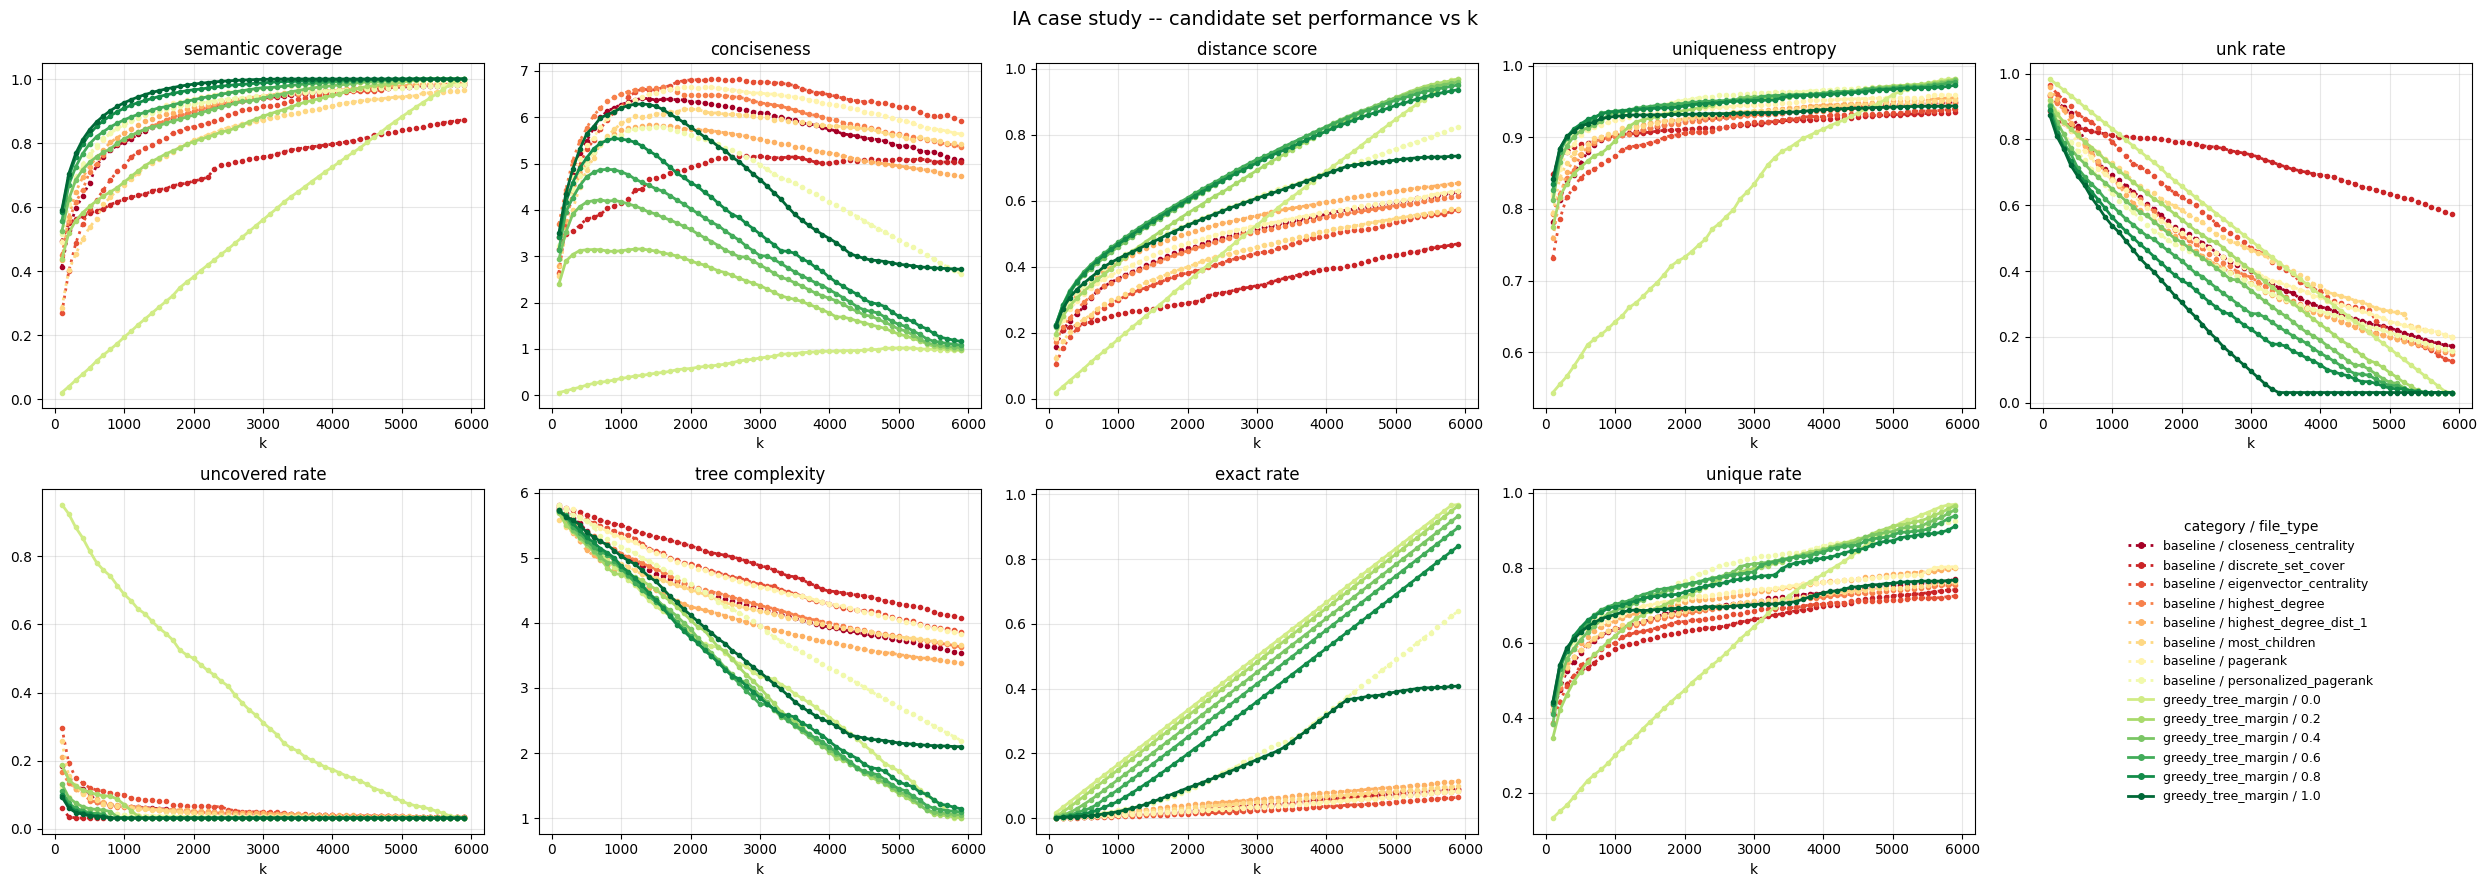

In [7]:
import matplotlib.pyplot as plt

metric_cols = ["semantic_coverage", "conciseness", "distance_score", "uniqueness_entropy",
               "unk_rate", "uncovered_rate", "tree_complexity", "exact_rate", "unique_rate"]

# greedy_tree_margin (6 lam values) + the single-ranking baselines, straight from disk -- robust
# to kernel restarts, this is the persisted, confirmed-complete output of the sweep above.
perf_df_all = pl.read_parquet(config.IAResults().perf_greedy_tree_path).sort(["category", "file_type", "k"])

series_keys = perf_df_all.select(["category", "file_type"]).unique().sort(["category", "file_type"]).rows()

# Hue-varied ordinal ramp: red -> yellow -> green across all series, fixed sorted order.
cmap = plt.get_cmap("RdYlGn")
colors = {key: cmap(i / max(len(series_keys) - 1, 1)) for i, key in enumerate(series_keys)}
# baseline = dotted, greedy_tree_margin = solid -- a second, category-level encoding on top of
# color so the two arms are distinguishable even without reading the legend.
linestyles = {key: (":" if key[0] == "baseline" else "-") for key in series_keys}

fig, axes = plt.subplots(2, 5, figsize=(25, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metric_cols):
    for category, file_type in series_keys:
        sub = perf_df_all.filter((pl.col("category") == category) & (pl.col("file_type") == file_type))
        ax.plot(sub["k"], sub[metric], color=colors[(category, file_type)], linestyle=linestyles[(category, file_type)],
                 linewidth=2, marker="o", markersize=3)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("k")
    ax.grid(alpha=0.3)

axes[-1].axis("off")
handles = [
    plt.Line2D([0], [0], color=colors[key], linestyle=linestyles[key], lw=2, marker="o", markersize=4,
               label=f"{key[0]} / {key[1]}")
    for key in series_keys
]
axes[-1].legend(handles=handles, loc="center", fontsize=9, title="category / file_type", frameon=False)

fig.suptitle("IA case study -- candidate set performance vs k", fontsize=14)
fig.tight_layout()
plt.show()

In [8]:
pl.read_parquet(config.TimelineData().patient_ids_and_index_lookup)

unique_patient_id,real_patient_id,patient_id,nb_patient_real_ids
str,list[i64],list[str],u32
"""ff2ded48797c5a9a8b3db128c3d236…",[417289],"[""ff2ded48797c5a9a8b3db128c3d236f2""]",1
"""f41cab7d23c6d427ffef8b25f7527b…",[444289],"[""f41cab7d23c6d427ffef8b25f7527bd8""]",1
"""35999b07e035266bb514cd446a0b2d…",[288136],"[""35999b07e035266bb514cd446a0b2dea""]",1
"""11fea8125bc575a46a058fe6d28c46…",[97127044],"[""11fea8125bc575a46a058fe6d28c4619""]",1
"""a056014323c49d29c860e18b6110a4…",[1129167],"[""a056014323c49d29c860e18b6110a470""]",1
…,…,…,…
"""77c50ea034b5dff858612de5ebeaee…",[615432],"[""77c50ea034b5dff858612de5ebeaee9f""]",1
"""c66557a9b129aba5a6d26c0d328822…",[747350],"[""c66557a9b129aba5a6d26c0d3288227e""]",1
"""c4850882b6aee6214d417404a22965…",[352607],"[""c4850882b6aee6214d417404a2296583""]",1
